### 0. Setup and Data Ingestion

In [1]:
# ==============================================================================
# CELL 1: SETUP, GLOBAL PARAMETERS, PLOTTING STYLES & GDELT DATA INGESTION
# ==============================================================================
import os
from datetime import datetime
from pathlib import Path
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas_datareader.data as web
import seaborn as sns
from group_lasso import GroupLasso
from sklearn.model_selection import TimeSeriesSplit
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')

# --- Plotting Configuration (Academic Standards) ---
sns.set_style('ticks')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 300,
})

# --- Global Parameters ---
START_DATE = datetime(2013, 1, 1)
END_DATE = datetime(2026, 7, 1)
MIN_INDEX_DATE = '2015-03-01'

# --- Load GDELT Data (France / US / UK) ---
dir_geo = Path('./data/indicators_geo_monthly')
dir_geo_uk = Path('./data/indicators_geo_monthly_UK')

# 1. Load France & US
if dir_geo.exists():
    files_geo = list(dir_geo.glob('*.parquet'))
    df_geo_main = pd.concat(
        [pd.read_parquet(f) for f in files_geo], ignore_index=True
    )
else:
    raise FileNotFoundError('⚠ Dossier ./data/indicators_geo_monthly introuvable.')

# 2. Load UK
if dir_geo_uk.exists():
    files_uk = list(dir_geo_uk.glob('*.parquet'))
    if len(files_uk) > 0:
        df_geo_uk = pd.concat(
            [pd.read_parquet(f) for f in files_uk], ignore_index=True
        )
        df_geo_uk['region_key'] = 'UK'
    else:
        df_geo_uk = pd.DataFrame()
else:
    df_geo_uk = pd.DataFrame()

# 3. Final Concatenation & Aggregation
df_geo = pd.concat([df_geo_main, df_geo_uk], ignore_index=True)

if 'region_key' in df_geo.columns:
    df_geo = (
        df_geo.groupby(['period', 'region_key']).max().reset_index().copy()
    )
    df_geo['period'] = pd.to_datetime(df_geo['period'])
    print('✓ Base RÉGIONALE GDELT chargée.')
    print(f"✓ Régions trouvées en mémoire : {df_geo['region_key'].unique().tolist()}")
    print(f'✓ Lignes totales : {len(df_geo)}')
else:
    print("⚠ ERREUR CRITIQUE : La colonne 'region_key' est absente.")

✓ Base RÉGIONALE GDELT chargée.
✓ Régions trouvées en mémoire : ['France', 'UK', 'US']
✓ Lignes totales : 411


### Functions

In [3]:
# ==============================================================================
# CELL 2: ECONOMETRIC FUNCTIONS & DATA PREPARATION LIBRARY
# ==============================================================================

def get_filtered_gdelt_cols(df):
    """Filter and retain only sentiment binary weight variables for target sectors."""
    allowed_prefixes = [
        'sent_bin_weight_agriculture_',
        'sent_bin_weight_commodities_',
        'sent_bin_weight_energy_',
        'sent_bin_weight_finance_',
        'sent_bin_weight_industry_',
    ]
    return [
        col for col in df.columns
        if any(str(col).startswith(prefix) for prefix in allowed_prefixes)
    ]


def strict_stationarize(df):
    """
    Stationarize variables via ADF test and first differencing if non-stationary.
    Dynamic winsorization/scaling is deferred to the recursive expanding window step.
    """
    df_stat = df.copy()
    diff_count = 0
    for col in df_stat.columns:
        valid_data = df_stat[col].dropna()
        if len(valid_data) > 10:
            if adfuller(valid_data, autolag='AIC')[1] >= 0.05:
                df_stat[col] = df_stat[col].diff()
                diff_count += 1
    return df_stat.dropna(), diff_count


def fetch_and_prep_macro_dynamic(region_config, start_date, end_date, region=None):
    """Download macroeconomic series, apply transformations, and generate 12 inflation lags."""
    macro_config = region_config['macro_vars']
    fred_tickers = {
        info['ticker']: var_name
        for var_name, info in macro_config.items()
        if not (region == 'France' and var_name == 'money')
        and not (region == 'UK' and info['ticker'] in ['IUMABEDR', 'LPMBD93', 'XUDLUSS'])
    }

    df = (
        web.DataReader(list(fred_tickers.keys()), 'fred', start_date, end_date)
        .rename(columns=fred_tickers)
        .resample('MS')
        .mean()
        if fred_tickers
        else pd.DataFrame()
    )

    # France M3 Money Supply from ECB API
    if region == 'France' and 'money' in macro_config:
        try:
            url_ecb = 'https://data-api.ecb.europa.eu/service/data/BSI/M.U2.Y.V.M30.X.1.U2.2300.Z01.E?format=csvdata'
            df_ecb = pd.read_csv(url_ecb)
            df_ecb['period'] = pd.to_datetime(df_ecb['TIME_PERIOD'])
            df_ecb = (
                df_ecb.set_index('period')
                .rename(columns={'OBS_VALUE': 'money'})[['money']]
                .resample('MS')
                .mean()
            )
            df = df.join(df_ecb, how='left') if not df.empty else df_ecb
        except Exception as e:
            print(f'⚠ Erreur BCE: {e}')

    # UK Local Bank of England Data
    if region == 'UK':
        df_local_all = pd.DataFrame()
        for var_name, info in macro_config.items():
            if info['ticker'] in ['IUMABEDR', 'LPMBD93', 'XUDLUSS']:
                ticker = info['ticker']
                file_path = f'data/BoE/{ticker}.csv'
                if Path(file_path).exists():
                    df_temp = pd.read_csv(file_path, encoding='ISO-8859-1')
                    df_temp['period'] = pd.to_datetime(df_temp.iloc[:, 0], errors='coerce')
                    df_temp = df_temp.dropna(subset=['period']).set_index('period')
                    val_col = next((c for c in df_temp.columns if ticker in c), None)
                    if val_col:
                        if df_temp[val_col].dtype == object:
                            df_temp[val_col] = (
                                df_temp[val_col]
                                .astype(str)
                                .str.replace(',', '', regex=False)
                                .str.strip()
                            )
                        series = (
                            pd.to_numeric(df_temp[val_col], errors='coerce')
                            .rename(var_name)
                            .resample('MS')
                            .mean()
                        )
                        df_local_all = (
                            series.to_frame()
                            if df_local_all.empty
                            else df_local_all.join(series, how='outer')
                        )
        if not df_local_all.empty:
            df = df.join(df_local_all, how='outer') if not df.empty else df_local_all

    # Transformations (pct_change or diff)
    final_cols = []
    for var_name, info in macro_config.items():
        if var_name in df.columns:
            if info['transform'] == 'pct_change':
                df[var_name] = df[var_name].pct_change() * 100
            elif info['transform'] == 'diff':
                df[var_name] = df[var_name].diff()
            final_cols.append(var_name)

    # 12 Inflation Lags
    for lag in range(1, 13):
        lag_name = f'inflation_lag{lag}'
        df[lag_name] = df['inflation'].shift(lag)
        final_cols.append(lag_name)

    return df[(df.index >= start_date) & (df.index <= end_date)][final_cols].dropna()


def expanding_stationarize_and_scale(df, min_periods=12):
    """
    Apply recursive (expanding window) winsorization and standardization
    to strictly prevent look-ahead bias.
    """
    df_transformed = df.copy()

    for col in df_transformed.columns:
        # 1. Dynamic Winsorization (5th & 95th percentiles)
        expanding_p05 = df_transformed[col].expanding(min_periods=min_periods).quantile(0.05)
        expanding_p95 = df_transformed[col].expanding(min_periods=min_periods).quantile(0.95)
        df_transformed[col] = df_transformed[col].clip(lower=expanding_p05, upper=expanding_p95)

        # 2. Dynamic Standardization (expanding mean and std)
        expanding_mean = df_transformed[col].expanding(min_periods=min_periods).mean()
        expanding_std = df_transformed[col].expanding(min_periods=min_periods).std()
        df_transformed[col] = (df_transformed[col] - expanding_mean) / expanding_std

    return df_transformed.dropna()


def prepare_region_dataset(
    region,
    config,
    df_geo,
    start_date=START_DATE,
    end_date=END_DATE,
    min_date=MIN_INDEX_DATE,
    drop_finance_outlier=True,
):
    """
    Unified pipeline to download macro data, filter GDELT indicators, stationarize,
    deseasonalize if configured, and apply recursive expanding scaling.
    """
    # 1. Macro preparation
    df_macro = fetch_and_prep_macro_dynamic(config, start_date, end_date, region=region)
    df_macro = df_macro[df_macro.index >= min_date]

    # 2. GDELT preparation
    cols_gdelt = get_filtered_gdelt_cols(df_geo)
    df_gdelt_raw = df_geo[df_geo['region_key'] == region].set_index('period')[cols_gdelt]
    if drop_finance_outlier and 'sent_cont_weight_finance_international_orgs' in df_gdelt_raw.columns:
        df_gdelt_raw = df_gdelt_raw.drop(columns=['sent_cont_weight_finance_international_orgs'])

    df_gdelt_stat, _ = strict_stationarize(df_gdelt_raw)

    # 3. Alignment & Seasonal Adjustment
    df_final = df_gdelt_stat.join(df_macro, how='inner')
    y_raw = df_final['inflation']

    if config.get('deseasonalize_y', False):
        y_corr = (y_raw - seasonal_decompose(y_raw, model='additive', period=12).seasonal).dropna()
    else:
        y_corr = y_raw.dropna()

    X_full = df_final.drop(columns=['inflation'])
    y_corr, X_contemp = y_corr.align(X_full, join='inner')

    # 4. Expanding Window Scaling (no look-ahead bias)
    y_expanding_mean = y_corr.expanding(min_periods=12).mean()
    y_centered = (y_corr - y_expanding_mean).dropna()
    X_scaled_full = expanding_stationarize_and_scale(X_contemp, min_periods=12)

    # Strict alignment
    y_centered, X_scaled_full = y_centered.align(X_scaled_full, join='inner')
    y_expanding_mean = y_expanding_mean.loc[y_centered.index]
    y_corr_aligned = y_corr.loc[y_centered.index]

    macro_base_cols = [
        c for c in X_scaled_full.columns
        if c in df_macro.columns and not c.startswith('inflation_lag') and c != 'inflation'
    ]
    active_gdelt_cols = [c for c in X_scaled_full.columns if c in cols_gdelt]

    return {
        'y_centered': y_centered,
        'X_scaled_full': X_scaled_full,
        'y_expanding_mean': y_expanding_mean,
        'y_corr_aligned': y_corr_aligned,
        'macro_base_cols': macro_base_cols,
        'gdelt_cols': active_gdelt_cols,
    }


def build_feature_groups(current_cols, macro_base_cols, active_lags):
    """
    Build group array for Group Lasso / Sparse Group Lasso:
      Group 0: Baseline macroeconomic variables
      Group 1: Endogenous inflation lags
      Group 2+: Individual GDELT news sectors
    """
    groups = []
    group_map = {}
    current_group_id = 2
    for var in current_cols:
        if var in macro_base_cols:
            groups.append(0)
        elif var in active_lags:
            groups.append(1)
        else:
            sector = var.split('_')[2]
            if sector not in group_map:
                group_map[sector] = current_group_id
                current_group_id += 1
            groups.append(group_map[sector])
    return np.array(groups)


def run_cv_sparse_group_lasso(X, y, groups):
    """Sparse Group Lasso with TimeSeriesSplit CV over a data-driven lambda & alpha grid."""
    tscv = TimeSeriesSplit(n_splits=5, gap=3)
    lambdas = np.logspace(-4, -1, 50)
    alphas = [0.50, 0.75, 0.95]

    best_mse, best_lbd, best_alpha = np.inf, None, None

    for alpha in alphas:
        for lbd in lambdas:
            sgl = GroupLasso(
                groups=groups,
                l1_reg=lbd * alpha,
                group_reg=lbd * (1 - alpha),
                fit_intercept=False,
                n_iter=1000,
                supress_warning=True,
            )
            mse_scores = []
            for train_idx, test_idx in tscv.split(X):
                sgl.fit(X.iloc[train_idx].values, y.iloc[train_idx].values.reshape(-1, 1))
                preds = sgl.predict(X.iloc[test_idx].values).flatten()
                mse_scores.append(np.mean((y.iloc[test_idx].values - preds) ** 2))

            mean_mse = np.mean(mse_scores)
            if mean_mse < best_mse:
                best_mse, best_lbd, best_alpha = mean_mse, lbd, alpha

    final_sgl = GroupLasso(
        groups=groups,
        l1_reg=best_lbd * best_alpha,
        group_reg=best_lbd * (1 - best_alpha),
        fit_intercept=False,
        n_iter=5000,
        supress_warning=True,
    )
    final_sgl.fit(X.values, y.values.reshape(-1, 1))
    return final_sgl.coef_.flatten(), best_lbd, best_alpha


def run_post_lasso_ols(X, y, selected_features):
    """Post-selection OLS inference and residual diagnostic via Ljung-Box test."""
    X_selected_with_const = sm.add_constant(X[selected_features])
    results = sm.OLS(y.values, X_selected_with_const.values).fit()

    post_lasso_df = pd.DataFrame({
        'Variable': ['Intercept'] + selected_features,
        'Coefficient': results.params,
        'P-value': results.pvalues,
        'CI_Lower': results.conf_int()[:, 0],
        'CI_Upper': results.conf_int()[:, 1],
    })

    lb_pval = acorr_ljungbox(results.resid, lags=[12], return_df=True)['lb_pvalue'].values[0]
    return post_lasso_df, results.rsquared, results.rsquared_adj, lb_pval

### 1. Inflation

In [20]:
# ==============================================================================
# CELL 3: REGIONAL MODEL CONFIGURATIONS (HEADLINE INFLATION)
# ==============================================================================
CONFIG_REGIONS = {
    'France': {
        'macro_vars': {
            'inflation': {'ticker': 'CP0000FRM086NEST', 'transform': 'pct_change'},
            'rate': {'ticker': 'IRSTCI01FRM156N', 'transform': 'diff'},
            'unemp': {'ticker': 'LRHUTTTTFRM156S', 'transform': 'diff'},
            'indpro': {'ticker': 'FRAPRINTO01GYSAM', 'transform': 'pct_change'},
            'money': {'ticker': 'BCE_M3_API', 'transform': 'none'},
            'fx': {'ticker': 'DEXUSEU', 'transform': 'pct_change'},
            'mich': {'ticker': 'CSINFT02FRM460S', 'transform': 'diff'},
            'oil': {'ticker': 'DCOILBRENTEU', 'transform': 'pct_change'},
        },
        'deseasonalize_y': True,
    },
    'US': {
        'macro_vars': {
            'inflation': {'ticker': 'CPIAUCSL', 'transform': 'pct_change'},
            'rate': {'ticker': 'FEDFUNDS', 'transform': 'diff'},
            'unemp': {'ticker': 'UNRATE', 'transform': 'diff'},
            'indpro': {'ticker': 'INDPRO', 'transform': 'pct_change'},
            'money': {'ticker': 'M2SL', 'transform': 'pct_change'},
            'fx': {'ticker': 'DEXUSEU', 'transform': 'pct_change'},
            'mich': {'ticker': 'MICH', 'transform': 'diff'},
            'oil': {'ticker': 'WTISPLC', 'transform': 'pct_change'},
        },
        'deseasonalize_y': False,
    },
    'UK': {
        'macro_vars': {
            'inflation': {'ticker': 'GBRCPIALLMINMEI', 'transform': 'pct_change'},
            'rate': {'ticker': 'IUMABEDR', 'transform': 'diff'},
            'unemp': {'ticker': 'LRHUTTTTGBM156S', 'transform': 'diff'},
            'indpro': {'ticker': 'GBRPRINTO01GYSAM', 'transform': 'pct_change'},
            'money': {'ticker': 'LPMBD93', 'transform': 'pct_change'},
            'fx': {'ticker': 'XUDLUSS', 'transform': 'pct_change'},
            'oil': {'ticker': 'DCOILBRENTEU', 'transform': 'pct_change'},
        },
        'deseasonalize_y': True,
    },
}

CONFIG_REGIONS_HEADLINE = CONFIG_REGIONS

In [22]:
# ==============================================================================
# CELL 4: ESTIMATION PIPELINE (MACRO + GDELT HYBRID SGL MODEL)
# ==============================================================================
final_results = {}
results_hybrid = final_results

for region, config in CONFIG_REGIONS.items():
    print('\n' + '=' * 80)
    print(f' PIPELINE ACADÉMIQUE : {region.upper()} (RECHERCHE DYNAMIQUE DE LAGS)')
    print('=' * 80)

    # 1. Préparation unifiée des données
    data = prepare_region_dataset(region, config, df_geo, START_DATE, END_DATE, MIN_INDEX_DATE)
    y_centered = data['y_centered']
    X_scaled_full = data['X_scaled_full']
    macro_base_cols = data['macro_base_cols']
    gdelt_cols = data['gdelt_cols']

    # 2. Recherche dynamique du nombre optimal de lags
    max_lags_to_test = 12
    best_iteration_sgl = None

    for current_lag in range(1, max_lags_to_test + 1):
        active_lags = [f'inflation_lag{i}' for i in range(1, current_lag + 1)]
        current_cols = macro_base_cols + active_lags + gdelt_cols
        X_current = X_scaled_full[current_cols]

        groups_array = build_feature_groups(current_cols, macro_base_cols, active_lags)

        # Modèle Sparse Group Lasso (Simon et al., 2013)
        coefs_sgl, lbd_sgl, alpha_sgl = run_cv_sparse_group_lasso(X_current, y_centered, groups_array)
        selected_vars_sgl = [current_cols[i] for i in range(len(current_cols)) if coefs_sgl[i] != 0]
        final_vars_sgl = list(set(macro_base_cols + active_lags + selected_vars_sgl))
        final_vars_sgl_sorted = (
            [v for v in macro_base_cols if v in final_vars_sgl]
            + [v for v in active_lags if v in final_vars_sgl]
            + sorted([v for v in gdelt_cols if v in final_vars_sgl])
        )

        df_sgl, r2_sgl, r2_adj_sgl, lb_pval_sgl = run_post_lasso_ols(
            X_current, y_centered, final_vars_sgl_sorted
        )
        best_iteration_sgl = (
            current_lag,
            final_vars_sgl_sorted,
            df_sgl,
            r2_sgl,
            r2_adj_sgl,
            lb_pval_sgl,
            lbd_sgl,
            alpha_sgl,
        )

        if lb_pval_sgl >= 0.05:
            print(f'  ✓ Bruit blanc validé au Lag {current_lag} (SGL Ljung-Box P-value : {lb_pval_sgl:.4f})')
            break
        else:
            print(f'  ↻ Autocorrélation résiduelle au Lag {current_lag} (P-value : {lb_pval_sgl:.4f}). Ajout du lag {current_lag+1}...')

    print('\n' + '=' * 80)
    print(f' RÉSULTATS COMPARATIFS FINAUX : {region.upper()} (STABILISÉ À {best_iteration_sgl[0]} LAG(S))')
    print('=' * 80)

    # Affichage Sparse Group Lasso
    lag_sgl, vars_sgl, df_sgl, r2_sgl, r2_adj_sgl, pval_sgl, lbd_sgl, alpha_sgl = best_iteration_sgl
    gdelt_sgl = [v for v in vars_sgl if v in gdelt_cols]

    print('\n\n▶ MODÈLE 2 : SPARSE GROUP LASSO (Simon et al., 2013) - Sélection intra-secteurs')
    print(f'  Tuning Data-Driven : Lambda = {lbd_sgl:.4f} | Alpha = {alpha_sgl:.2f}')
    print(f'  Variables totales (OLS) : {len(vars_sgl)} (dont {len(gdelt_sgl)} GDELT)')
    print(f'  R-squared (Global/Adj) : {r2_sgl:.4f} / {r2_adj_sgl:.4f}')
    print(f'  Ljung-Box P-value : {pval_sgl:.4f}')
    print('-' * 60)
    print(df_sgl.to_string(index=False))

    final_results[region] = {
        'SGL_Model': {
            'Vars': vars_sgl,
            'OLS': df_sgl,
            'R2_adj': r2_adj_sgl,
            'Optimal_Alpha': alpha_sgl,
        }
    }


 PIPELINE ACADÉMIQUE : FRANCE (RECHERCHE DYNAMIQUE DE LAGS)
  ↻ Autocorrélation résiduelle au Lag 1 (P-value : 0.0106). Ajout du lag 2...
  ↻ Autocorrélation résiduelle au Lag 2 (P-value : 0.0115). Ajout du lag 3...
  ↻ Autocorrélation résiduelle au Lag 3 (P-value : 0.0075). Ajout du lag 4...
  ↻ Autocorrélation résiduelle au Lag 4 (P-value : 0.0274). Ajout du lag 5...
  ✓ Bruit blanc validé au Lag 5 (SGL Ljung-Box P-value : 0.5737)

 RÉSULTATS COMPARATIFS FINAUX : FRANCE (STABILISÉ À 5 LAG(S))


▶ MODÈLE 2 : SPARSE GROUP LASSO (Simon et al., 2013) - Sélection intra-secteurs
  Tuning Data-Driven : Lambda = 0.0121 | Alpha = 0.50
  Variables totales (OLS) : 29 (dont 17 GDELT)
  R-squared (Global/Adj) : 0.5438 / 0.3764
  Ljung-Box P-value : 0.5737
------------------------------------------------------------
                                       Variable  Coefficient  P-value  CI_Lower  CI_Upper
                                      Intercept    -0.054914 0.847303 -0.620683  0.510856
   

#### Robustness - only macro

In [6]:
# ==============================================================================
# CELL 5: BENCHMARK ESTIMATION (MACRO + LAGS ONLY - ARX VIA OLS)
# ==============================================================================
final_results_macro_only = {}

for region, config in CONFIG_REGIONS.items():
    print('\n' + '=' * 80)
    print(f' BENCHMARK MACRO-ONLY : {region.upper()} (RECHERCHE DYNAMIQUE DE LAGS)')
    print('=' * 80)

    # 1. Préparation des données (mêmes dates et échantillon N via la fonction unifiée)
    data = prepare_region_dataset(region, config, df_geo, START_DATE, END_DATE, MIN_INDEX_DATE)
    y_centered = data['y_centered']
    X_scaled_full = data['X_scaled_full']
    macro_base_cols = data['macro_base_cols']

    # 2. Recherche dynamique du nombre de lags (OLS Standard)
    max_lags_to_test = 12
    best_iteration_arx = None

    for current_lag in range(1, max_lags_to_test + 1):
        active_lags = [f'inflation_lag{i}' for i in range(1, current_lag + 1)]
        current_cols = macro_base_cols + active_lags  # Uniquement macro + lags
        X_current = X_scaled_full[current_cols]

        X_current_with_const = sm.add_constant(X_current)
        results = sm.OLS(y_centered.values, X_current_with_const.values).fit()

        lb_pval = acorr_ljungbox(results.resid, lags=[12], return_df=True)['lb_pvalue'].values[0]

        post_arx_df = pd.DataFrame({
            'Variable': ['Intercept'] + current_cols,
            'Coefficient': results.params,
            'P-value': results.pvalues,
        })

        best_iteration_arx = (
            current_lag,
            current_cols,
            post_arx_df,
            results.rsquared,
            results.rsquared_adj,
            lb_pval,
        )

        if lb_pval >= 0.05:
            print(f'  ✓ Bruit blanc validé au Lag {current_lag} (OLS Ljung-Box P-value : {lb_pval:.4f})')
            break
        else:
            print(f'  ↻ Autocorrélation résiduelle au Lag {current_lag} (P-value : {lb_pval:.4f}). Ajout du lag {current_lag+1}...')

    # 3. Affichage des résultats du Benchmark
    lag_arx, vars_arx, df_arx, r2_arx, r2_adj_arx, pval_arx = best_iteration_arx

    print('\n' + '=' * 80)
    print(f' RÉSULTATS FINAUX BENCHMARK MACRO : {region.upper()} (STABILISÉ À {lag_arx} LAG(S))')
    print('=' * 80)
    print('  Modèle : ARX (OLS Standard)')
    print(f'  Variables : {len(vars_arx)} (Macroéconomiques + Lags uniquement)')
    print(f'  R-squared (Global/Adj) : {r2_arx:.4f} / {r2_adj_arx:.4f}')
    print(f'  Ljung-Box P-value : {pval_arx:.4f}')
    print('-' * 60)
    print(df_arx.to_string(index=False))

    final_results_macro_only[region] = {
        'Vars': vars_arx,
        'OLS': df_arx,
        'R2_adj': r2_adj_arx,
    }


 BENCHMARK MACRO-ONLY : FRANCE (RECHERCHE DYNAMIQUE DE LAGS)
  ✓ Bruit blanc validé au Lag 1 (OLS Ljung-Box P-value : 0.1501)

 RÉSULTATS FINAUX BENCHMARK MACRO : FRANCE (STABILISÉ À 1 LAG(S))
  Modèle : ARX (OLS Standard)
  Variables : 8 (Macroéconomiques + Lags uniquement)
  R-squared (Global/Adj) : 0.1724 / 0.1062
  Ljung-Box P-value : 0.1501
------------------------------------------------------------
      Variable  Coefficient  P-value
     Intercept    -0.237533 0.418332
          rate     0.074216 0.008160
         unemp     0.010279 0.788207
        indpro    -0.076791 0.137386
         money     0.161756 0.325406
            fx    -0.029377 0.520196
          mich     0.032863 0.341116
           oil     0.126652 0.005581
inflation_lag1    -0.033666 0.447760

 BENCHMARK MACRO-ONLY : US (RECHERCHE DYNAMIQUE DE LAGS)
  ✓ Bruit blanc validé au Lag 1 (OLS Ljung-Box P-value : 0.3088)

 RÉSULTATS FINAUX BENCHMARK MACRO : US (STABILISÉ À 1 LAG(S))
  Modèle : ARX (OLS Standard)
  Va

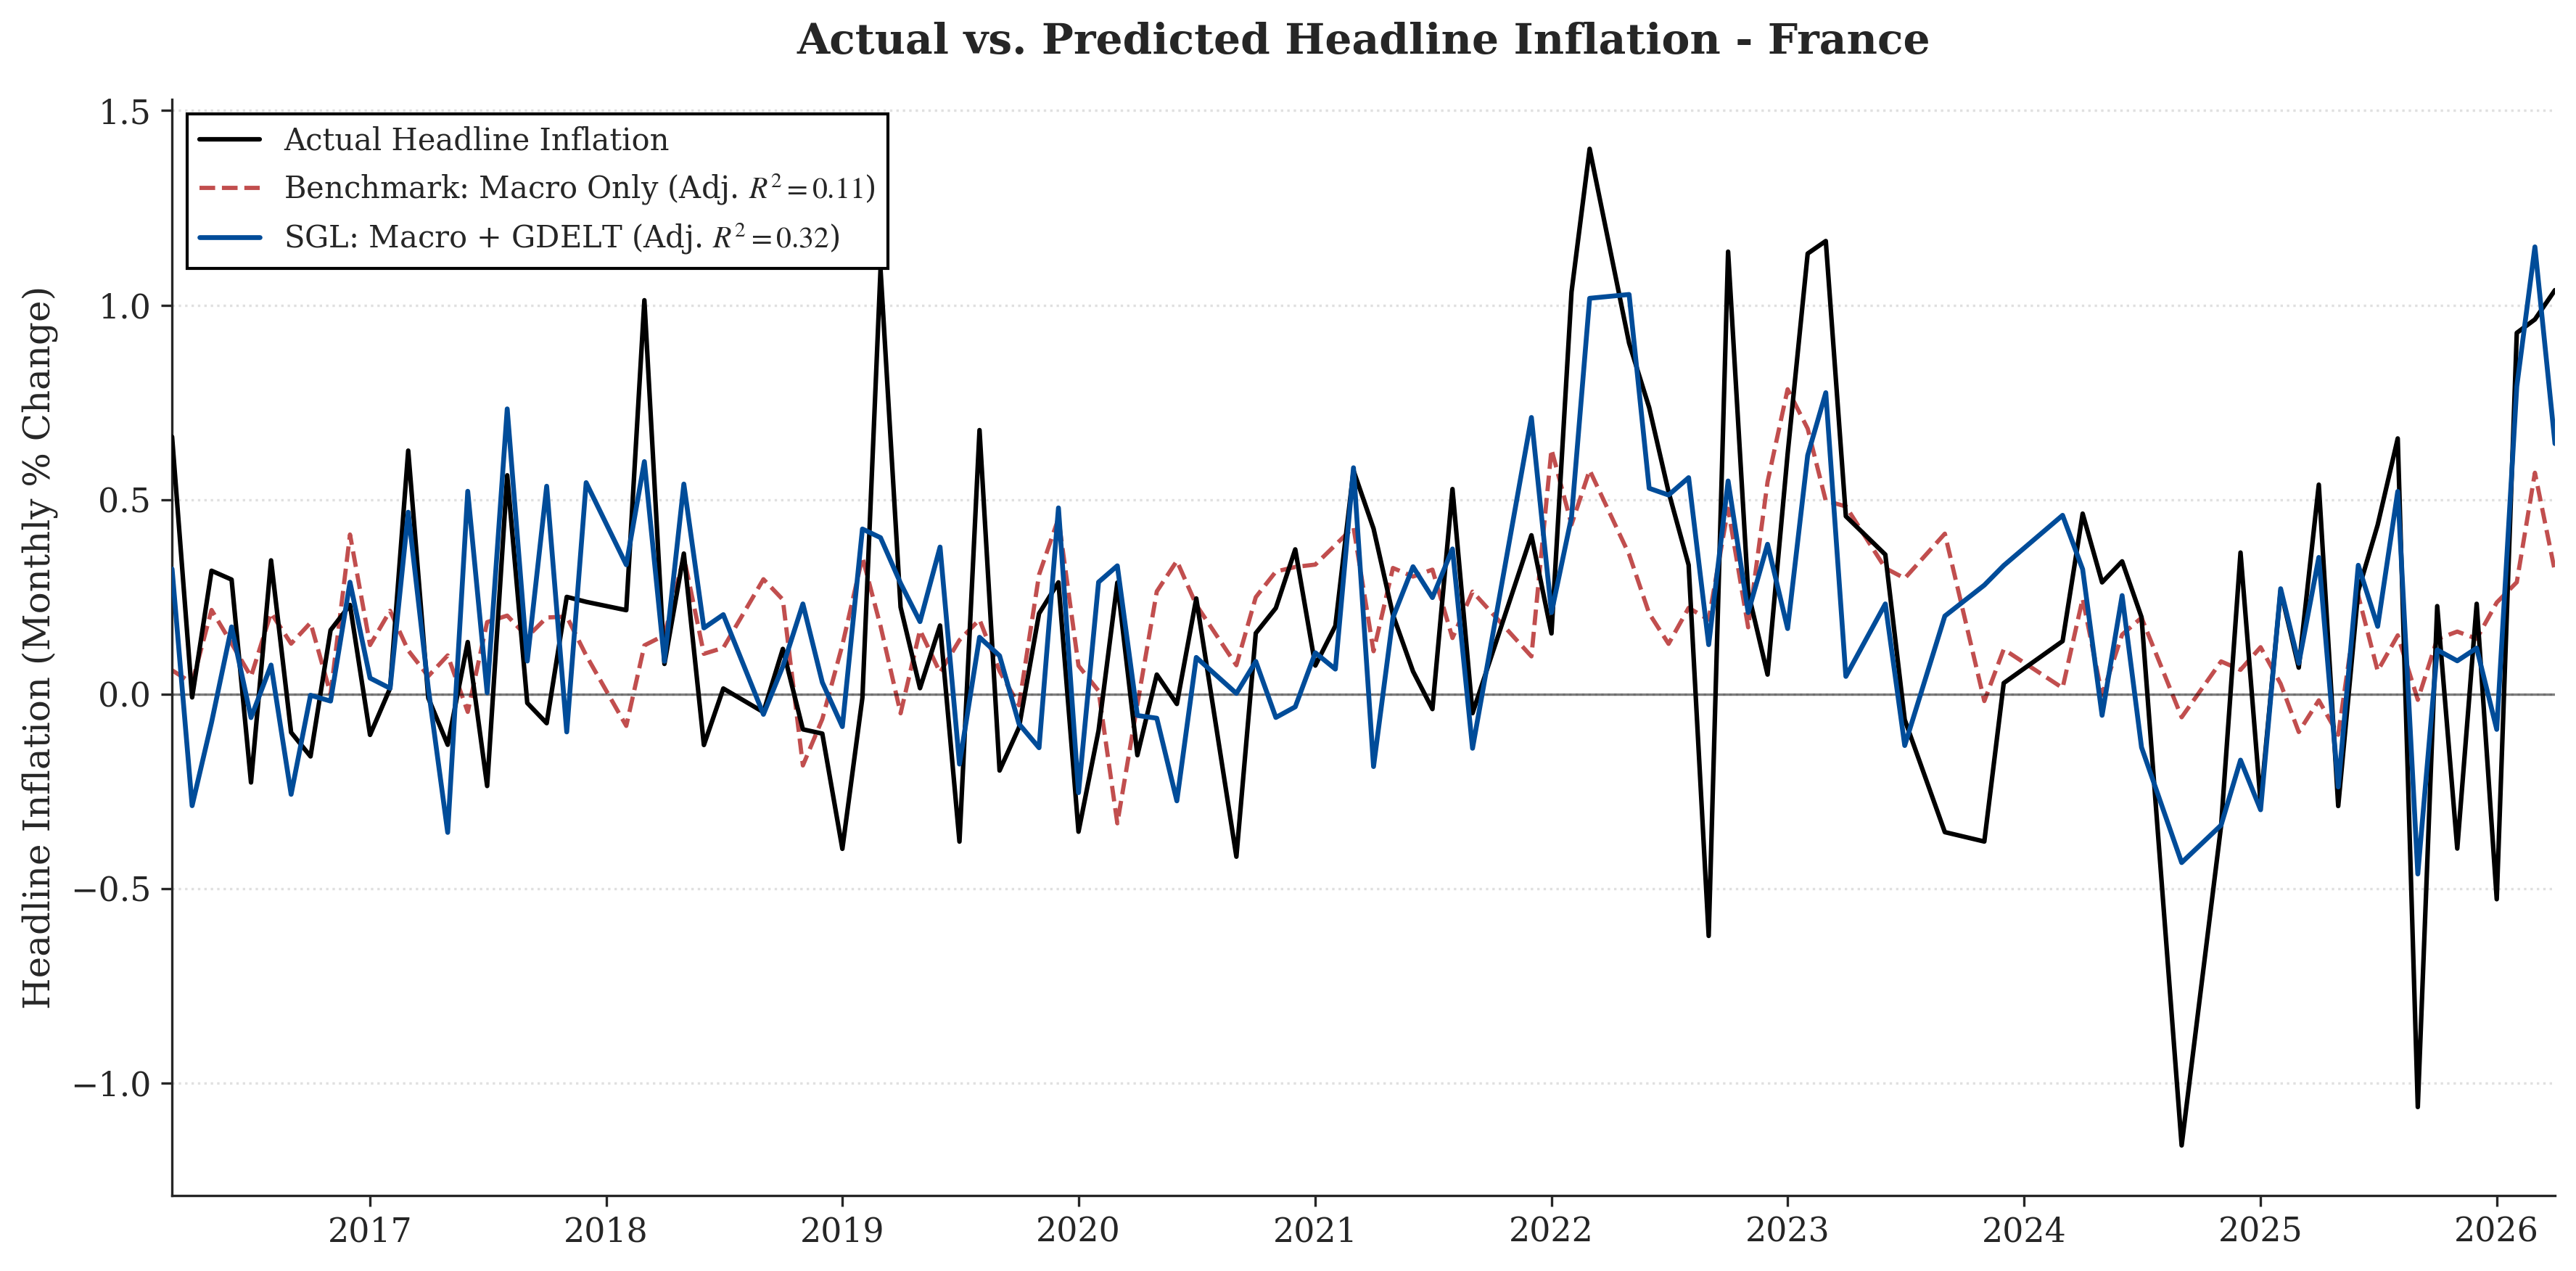

In [21]:
# ==============================================================================
# CELL 6: VISUALIZATION (ACTUAL VS. PREDICTED HEADLINE INFLATION)
# ==============================================================================
region = 'France'
config = CONFIG_REGIONS_HEADLINE[region] if 'CONFIG_REGIONS_HEADLINE' in globals() else CONFIG_REGIONS[region]

# 1. Préparation unifiée des données et alignement temporel
data = prepare_region_dataset(region, config, df_geo, START_DATE, END_DATE, MIN_INDEX_DATE)
y_centered = data['y_centered']
X_scaled_full = data['X_scaled_full']
y_expanding_mean = data['y_expanding_mean']
y_corr_aligned = data['y_corr_aligned']

# 2. Reconstruction des Prédictions à l'échelle réelle (+ y_expanding_mean)
# A. Benchmark : Macro-Only
vars_macro = final_results_macro_only[region]['Vars']
X_macro = sm.add_constant(X_scaled_full[vars_macro])
y_pred_macro_centered = sm.OLS(y_centered.values, X_macro.values).fit().fittedvalues
y_pred_macro = y_pred_macro_centered + y_expanding_mean.values

# B. Modèle Proposé : Hybride SGL (GDELT + Macro)
hybrid_dict = results_hybrid[region] if 'results_hybrid' in globals() and region in results_hybrid else final_results[region]
vars_hybrid = hybrid_dict['SGL_Model']['Vars']
X_hybrid = sm.add_constant(X_scaled_full[vars_hybrid])
y_pred_hybrid_centered = sm.OLS(y_centered.values, X_hybrid.values).fit().fittedvalues
y_pred_hybrid = y_pred_hybrid_centered + y_expanding_mean.values

# Extraction des R2 ajustés
r2_adj_macro = final_results_macro_only[region]['R2_adj']
r2_adj_hybrid = hybrid_dict['SGL_Model']['R2_adj']

# 3. Tracé du Graphique (Plotting)
fig, ax = plt.subplots(figsize=(12, 6))

# Ligne 1 : Vraie inflation (alignée)
ax.plot(
    y_corr_aligned.index,
    y_corr_aligned.values,
    label='Actual Headline Inflation',
    color='black',
    linewidth=1.5,
    zorder=3,
)

# Ligne 2 : Benchmark Macro (Pointillés rouges)
ax.plot(
    y_corr_aligned.index,
    y_pred_macro,
    label=f'Benchmark: Macro Only (Adj. $R^2 = {r2_adj_macro:.2f}$)',
    color='#b22222',
    linestyle='--',
    linewidth=1.4,
    alpha=0.8,
    zorder=2,
)

# Ligne 3 : Modèle SGL Hybride (Trait plein bleu)
ax.plot(
    y_corr_aligned.index,
    y_pred_hybrid,
    label=f'SGL: Macro + GDELT (Adj. $R^2 = {r2_adj_hybrid:.2f}$)',
    color='#004c99',
    linestyle='-',
    linewidth=1.6,
    zorder=4,
)

# 4. Habillage et Mise en Forme
ax.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.5)
ax.set_xlim(y_corr_aligned.index.min(), y_corr_aligned.index.max())
ax.set_ylabel('Headline Inflation (Monthly % Change)')
ax.set_title(f'Actual vs. Predicted Headline Inflation - {region}', pad=15, fontweight='bold')

# Formattage de l'axe X (Années)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate(rotation=0, ha='center')

# Légende & Grille
ax.legend(loc='upper left', frameon=True, edgecolor='black', fancybox=False, facecolor='white', framealpha=1)
ax.grid(True, which='major', axis='y', linestyle=':', alpha=0.6)
sns.despine()

# Sauvegarde pour LaTeX
os.makedirs('./latex_tables', exist_ok=True)
plt.savefig(f'./latex_tables/Macro_Decoupling_{region}.pdf', format='pdf', bbox_inches='tight')

plt.tight_layout()
plt.show()

#### Robustness - no group macro

In [17]:
# ==============================================================================
# CELL 7: ROBUSTNESS CONFIGURATION (NO GROUP MACRO - GDELT + INFLATION LAGS ONLY)
# ==============================================================================
CONFIG_REGIONS_NO_MACRO = {
    'France': {
        'macro_vars': {
            'inflation': {'ticker': 'CP0000FRM086NEST', 'transform': 'pct_change'}
        },
        'deseasonalize_y': True,
    },
    'US': {
        'macro_vars': {
            'inflation': {'ticker': 'CPIAUCSL', 'transform': 'pct_change'}
        },
        'deseasonalize_y': False,
    },
    'UK': {
        'macro_vars': {
            'inflation': {'ticker': 'GBRCPIALLMINMEI', 'transform': 'pct_change'}
        },
        'deseasonalize_y': True,
    },
}

CONFIG_REGIONS = CONFIG_REGIONS_NO_MACRO

In [18]:
# ==============================================================================
# CELL 8: ROBUSTNESS ESTIMATION (GDELT + INFLATION LAGS ONLY VIA SGL)
# ==============================================================================
final_results_no_macro = {}
final_results = final_results_no_macro

for region, config in CONFIG_REGIONS.items():
    print('\n' + '=' * 80)
    print(f' PIPELINE ACADÉMIQUE : {region.upper()} (RECHERCHE DYNAMIQUE DE LAGS)')
    print('=' * 80)

    # 1. Préparation unifiée des données
    data = prepare_region_dataset(region, config, df_geo, START_DATE, END_DATE, MIN_INDEX_DATE)
    y_centered = data['y_centered']
    X_scaled_full = data['X_scaled_full']
    macro_base_cols = data['macro_base_cols']
    gdelt_cols = data['gdelt_cols']

    # 2. Recherche dynamique du nombre optimal de lags
    max_lags_to_test = 12
    best_iteration_sgl = None

    for current_lag in range(1, max_lags_to_test + 1):
        active_lags = [f'inflation_lag{i}' for i in range(1, current_lag + 1)]
        current_cols = macro_base_cols + active_lags + gdelt_cols
        X_current = X_scaled_full[current_cols]

        groups_array = build_feature_groups(current_cols, macro_base_cols, active_lags)

        # Modèle Sparse Group Lasso (Simon et al., 2013)
        coefs_sgl, lbd_sgl, alpha_sgl = run_cv_sparse_group_lasso(X_current, y_centered, groups_array)
        selected_vars_sgl = [current_cols[i] for i in range(len(current_cols)) if coefs_sgl[i] != 0]
        final_vars_sgl = list(set(macro_base_cols + active_lags + selected_vars_sgl))
        final_vars_sgl_sorted = (
            [v for v in macro_base_cols if v in final_vars_sgl]
            + [v for v in active_lags if v in final_vars_sgl]
            + sorted([v for v in gdelt_cols if v in final_vars_sgl])
        )

        df_sgl, r2_sgl, r2_adj_sgl, lb_pval_sgl = run_post_lasso_ols(
            X_current, y_centered, final_vars_sgl_sorted
        )
        best_iteration_sgl = (
            current_lag,
            final_vars_sgl_sorted,
            df_sgl,
            r2_sgl,
            r2_adj_sgl,
            lb_pval_sgl,
            lbd_sgl,
            alpha_sgl,
        )

        if lb_pval_sgl >= 0.05:
            print(f'  ✓ Bruit blanc validé au Lag {current_lag} (SGL Ljung-Box P-value : {lb_pval_sgl:.4f})')
            break
        else:
            print(f'  ↻ Autocorrélation résiduelle au Lag {current_lag} (P-value : {lb_pval_sgl:.4f}). Ajout du lag {current_lag+1}...')

    print('\n' + '=' * 80)
    print(f' RÉSULTATS COMPARATIFS FINAUX : {region.upper()} (STABILISÉ À {best_iteration_sgl[0]} LAG(S))')
    print('=' * 80)

    # Affichage Sparse Group Lasso
    lag_sgl, vars_sgl, df_sgl, r2_sgl, r2_adj_sgl, pval_sgl, lbd_sgl, alpha_sgl = best_iteration_sgl
    gdelt_sgl = [v for v in vars_sgl if v in gdelt_cols]

    print('\n\n▶ MODÈLE 2 : SPARSE GROUP LASSO (Simon et al., 2013) - Sélection intra-secteurs')
    print(f'  Tuning Data-Driven : Lambda = {lbd_sgl:.4f} | Alpha = {alpha_sgl:.2f}')
    print(f'  Variables totales (OLS) : {len(vars_sgl)} (dont {len(gdelt_sgl)} GDELT)')
    print(f'  R-squared (Global/Adj) : {r2_sgl:.4f} / {r2_adj_sgl:.4f}')
    print(f'  Ljung-Box P-value : {pval_sgl:.4f}')
    print('-' * 60)
    print(df_sgl.to_string(index=False))

    final_results_no_macro[region] = {
        'SGL_Model': {
            'Vars': vars_sgl,
            'OLS': df_sgl,
            'R2_adj': r2_adj_sgl,
            'Optimal_Alpha': alpha_sgl,
        }
    }


 PIPELINE ACADÉMIQUE : FRANCE (RECHERCHE DYNAMIQUE DE LAGS)
  ↻ Autocorrélation résiduelle au Lag 1 (P-value : 0.0014). Ajout du lag 2...
  ↻ Autocorrélation résiduelle au Lag 2 (P-value : 0.0034). Ajout du lag 3...
  ↻ Autocorrélation résiduelle au Lag 3 (P-value : 0.0065). Ajout du lag 4...
  ↻ Autocorrélation résiduelle au Lag 4 (P-value : 0.0146). Ajout du lag 5...
  ✓ Bruit blanc validé au Lag 5 (SGL Ljung-Box P-value : 0.3645)

 RÉSULTATS COMPARATIFS FINAUX : FRANCE (STABILISÉ À 5 LAG(S))


▶ MODÈLE 2 : SPARSE GROUP LASSO (Simon et al., 2013) - Sélection intra-secteurs
  Tuning Data-Driven : Lambda = 0.0244 | Alpha = 0.50
  Variables totales (OLS) : 29 (dont 24 GDELT)
  R-squared (Global/Adj) : 0.4976 / 0.3155
  Ljung-Box P-value : 0.3645
------------------------------------------------------------
                                       Variable  Coefficient  P-value  CI_Lower  CI_Upper
                                      Intercept     0.105038 0.232374 -0.068665  0.278740
   